In [233]:
import os
import random
import numpy as np
from tqdm import tqdm
from ase.build import bcc110, molecule
from ase.constraints import FixAtoms
# Build the sparse bonding matrix for the system
from ase.neighborlist import NeighborList
from ase.data import covalent_radii
from ase.visualize import view
import pandas as pd
from matplotlib import pyplot as plt

from mace.calculators import mace_mp

from ase.calculators.plumed import Plumed
from ase.md.langevin import Langevin
from ase.io import read, write
from ase import units

os.environ["PLUMED_KERNEL"] = "/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib"
calc = mace_mp(model="/Users/c_yang/Documents/play_with_code/mace/mace/calculators/foundations_models/mace-mpa-0-medium.model")

from utils import plumed_to_pandas, dos_2D
plt.style.use("acs")

Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


# Ref this paper to see if we can build them step by step
https://doi.org/10.1021/acscatal.4c01920

In [48]:
# In that paper, they used 4x6x5 bcc110 Fe slab, as a toy model
# we decrease the size to 4x4x3 for faster computation
fe110 = bcc110('Fe', size=(4, 4, 3), vacuum=10)

# Define some regions
z_max = max(fe110.get_positions()[:, 2])
z_min = min(fe110.get_positions()[:, 2])
# Buffer region
z_buff = (z_max + 3.0, z_max + 5.0)


fixed = [atom.index for atom in fe110 if atom.position[2] < z_max - 1.5]
fe110.set_constraint(FixAtoms(indices=fixed))

# Set the surface model to tag 1
for atom in fe110:
    atom.tag = 1

In [49]:
mol = molecule('NH3')
z_mol = mol.positions[:, 2].min()
random_z_start = random.uniform(z_buff[0] - z_mol, z_buff[1] - z_mol)
mol.translate([2.0, 2.0, random_z_start])

fe110 += mol

In [50]:
view(fe110, viewer="x3d")

# Adsorption descriptor

In [ ]:
timestep = 1 * units.fs
ps = 1000 * units.fs
temp = 700 #K

com = [i + 1 for i in range(len(fe110)) if fe110.get_tags()[i] == 0]

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"com: COM ATOMS={','.join(map(str, com))}",
         f"cn: COORDINATIONNUMBER SPECIESA=com SPECIESB={','.join(map(str, com))} " +
         " SWITCH={RATIONAL R_0=1.5 NN=8 MM=16 D_MAX=8} MEAN",
         "opes: OPES_METAD_EXPLORE ARG=com.z PACE=200 BARRIER=0.5",
         f"uwall: UWALLS DATA=com.z AT={z_buff[1]} KAPPA=2000 EXP=2",
         "PRINT ARG=com.x,com.y,com.z,cn.mean STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = fe110.copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=units.kB*temp)

dyn = Langevin(atoms, timestep, temperature_K=temp, friction=1,
               fixcm=True, trajectory='UnbiasMD.traj')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 52
PLUMED: File suffix: 
PLUMED: Timestep: 0.001000
PLUMED: KbT: 5.820122
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

In [60]:
rtype = 'ads'
cv_ads = plumed_to_pandas(rtype + '.COLVAR')
dos_ads = dos_2D(cv_ads['com.z'], cv_ads['cn_mean'], bins=[50, 10], density=False)
xy_dos_ads = dos_2D(cv_ads['com.x'], cv_ads['com.y'], bins=[10, 10], density=False)

Text(0.5, 1.0, 'Lateral Distribution')

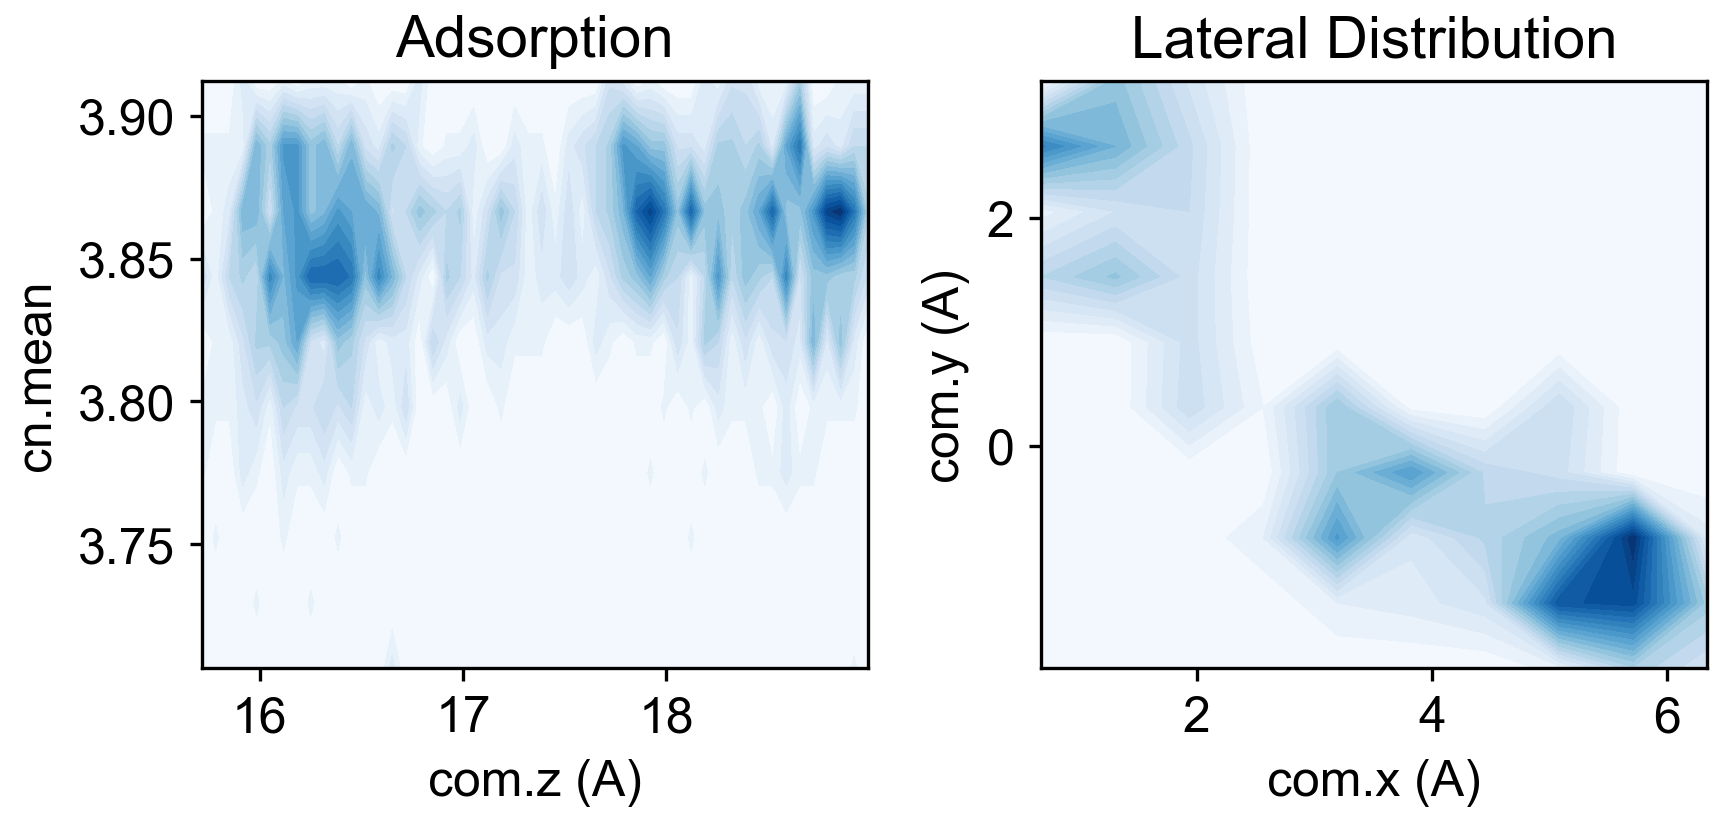

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), tight_layout=True)
ax[0].contourf(dos_ads[1][:-1], dos_ads[2][:-1], dos_ads[0], levels=20, cmap='Blues')
ax[0].set_xlabel('com.z (A)')
ax[0].set_ylabel('cn.mean')
ax[0].set_title('Adsorption')
xy_dos_ads = dos_2D(cv_ads['com.x'], cv_ads['com.y'], bins=[10, 10], density=False)
ax[1].contourf(xy_dos_ads[1][:-1], xy_dos_ads[2][:-1], xy_dos_ads[0], levels=20, cmap='Blues')
ax[1].set_xlabel('com.x (A)')
ax[1].set_ylabel('com.y (A)')
ax[1].set_title('Lateral Distribution')

In [247]:
def metropolis_sampling(traj, colvar, calc=False, skip=10, temp=300):
    """
    Metropolis sampling for enhanced sampling.
    Parameters
    ----------
    traj : ASE trajectory object
        The trajectory to sample from.
    colvar : pandas DataFrame
        The collective variable data corresponding to the trajectory.
    """

    traj = read(traj, index=':')
    traj = traj[::skip]
    colvar = plumed_to_pandas(colvar)
    traj_db = []
    colvar_db = []
    for i, atom in tqdm(enumerate(traj), total=len(traj), desc="Metropolis Sampling"):
        if calc:
            tmp_atom = atom.copy()
            tmp_atom.calc = calc
            ene = tmp_atom.get_potential_energy()
        else:
            tmp_atom = atom
            ene = tmp_atom.get_potential_energy()
            tmp_atom.calc.results['energy'] = float(ene)

        if len(traj_db) == 0:
            traj_db.append((tmp_atom))
            colvar_db.append(colvar.iloc[i])
        else:
            # Metropolis criterion
            delta_e = ene - traj_db[-1].get_potential_energy()
            if delta_e < 0:
                traj_db.append((tmp_atom))
                colvar_db.append(colvar.iloc[i])
            else:
                prob = np.exp(-delta_e / (units.kB * temp))
                if random.random() < prob:
                    traj_db.append((tmp_atom))
                    colvar_db.append(colvar.iloc[i])
    return traj_db, pd.DataFrame(colvar_db)


In [248]:
mdb, mcv_ads = metropolis_sampling("adsMD.traj", "ads.COLVAR", calc=False, temp=4000)
#mcv_ads = plumed_to_pandas(rtype + '.COLVAR')
mdos_ads = dos_2D(mcv_ads['com.z'], mcv_ads['cn_mean'], bins=[50, 10], density=False)
mxy_dos_ads = dos_2D(mcv_ads['com.x'], mcv_ads['com.y'], bins=[50, 10], density=False)

# Filter the sampled database based on z and energy
mdb_index = list(range(len(mdb)))
mdb_index.sort(key=lambda i: (mcv_ads['com.z'].iloc[i], mdb[i].get_potential_energy()))

Metropolis Sampling:   0%|          | 0/984 [00:00<?, ?it/s]/var/folders/zx/j6djtfr16010vng0mhcs8bn80000gn/T/ipykernel_52202/3846051625.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tmp_atom.calc.results['energy'] = float(ene)
Metropolis Sampling: 100%|██████████| 984/984 [00:00<00:00, 11775.84it/s]


Text(0.5, 1.0, 'Lateral Distribution (MS)')

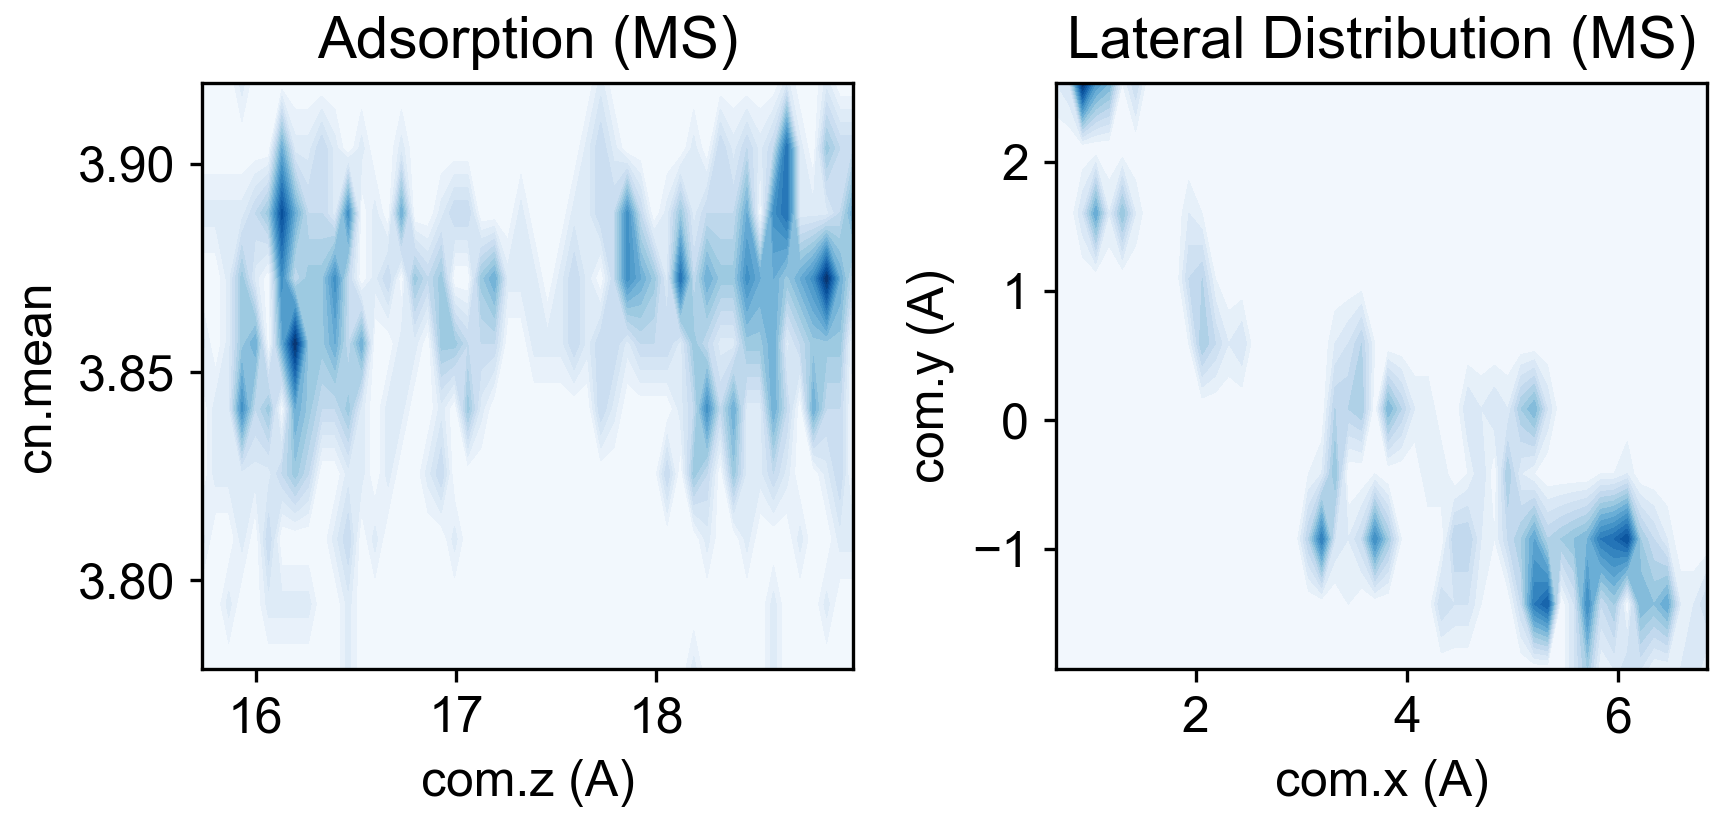

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), tight_layout=True)
ax[0].contourf(mdos_ads[1][:-1], mdos_ads[2][:-1], mdos_ads[0], levels=20, cmap='Blues')
ax[0].set_xlabel('com.z (A)')
ax[0].set_ylabel('cn.mean')
ax[0].set_title('Adsorption (MS)')
ax[1].contourf(mxy_dos_ads[1][:-1], mxy_dos_ads[2][:-1], mxy_dos_ads[0], levels=20, cmap='Blues')
ax[1].set_xlabel('com.x (A)')
ax[1].set_ylabel('com.y (A)')
ax[1].set_title('Lateral Distribution (MS)')

In [249]:
view(mdb[mdb_index[0]])

<Popen: returncode: None args: ['/Users/c_yang/repo/GS_GMLIP/.venv/bin/pytho...>

# Diffusion descriptor

In [252]:
timestep = 1 * units.fs
ps = 1000 * units.fs
temp = 700 #K


com = [i + 1 for i in range(len(fe110)) if fe110.get_tags()[i] == 0]

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"com: COM ATOMS={','.join(map(str, com))}",
         f"cn: COORDINATIONNUMBER SPECIESA=com SPECIESB={','.join(map(str, com))} " +
         " SWITCH={RATIONAL R_0=1.5 NN=8 MM=16 D_MAX=8} MEAN",
         "opes: OPES_METAD_EXPLORE ARG=com.x,com.y PACE=200 BARRIER=0.5",
         #f"uwall: UWALLS DATA=com.x,com.y AT={z_buff[1]} KAPPA=2000 EXP=2",
         "PRINT ARG=com.x,com.y,com.z,cn.mean STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = mdb[mdb_index[0]].copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=units.kB*temp)

dyn = Langevin(atoms, timestep, temperature_K=temp, friction=1,
               fixcm=True, trajectory='UnbiasMD.traj')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 52
PLUMED: File suffix: 
PLUMED: Timestep: 0.001000
PLUMED: KbT: 5.820122
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

True

In [283]:
rtype = 'diff'
cv_diff = plumed_to_pandas(rtype + '.COLVAR')
c = fe110.cell
scale_xy = (c.scaled_positions(cv_diff[['com.x', 'com.y', 'com.z']].values)[:, :2] + 9999)%1
cart_xy = c.cartesian_positions(np.c_[scale_xy, np.zeros(len(scale_xy))])[:, :2]

xy_dos_diff = dos_2D(cart_xy[:, 0], cart_xy[:, 1], bins=[10, 10], density=False)
dos_diff = dos_2D(cv_diff['com.z'], cv_diff['cn_mean'], bins=[10, 10], density=False)

Text(0.5, 1.0, 'Lateral Distribution')

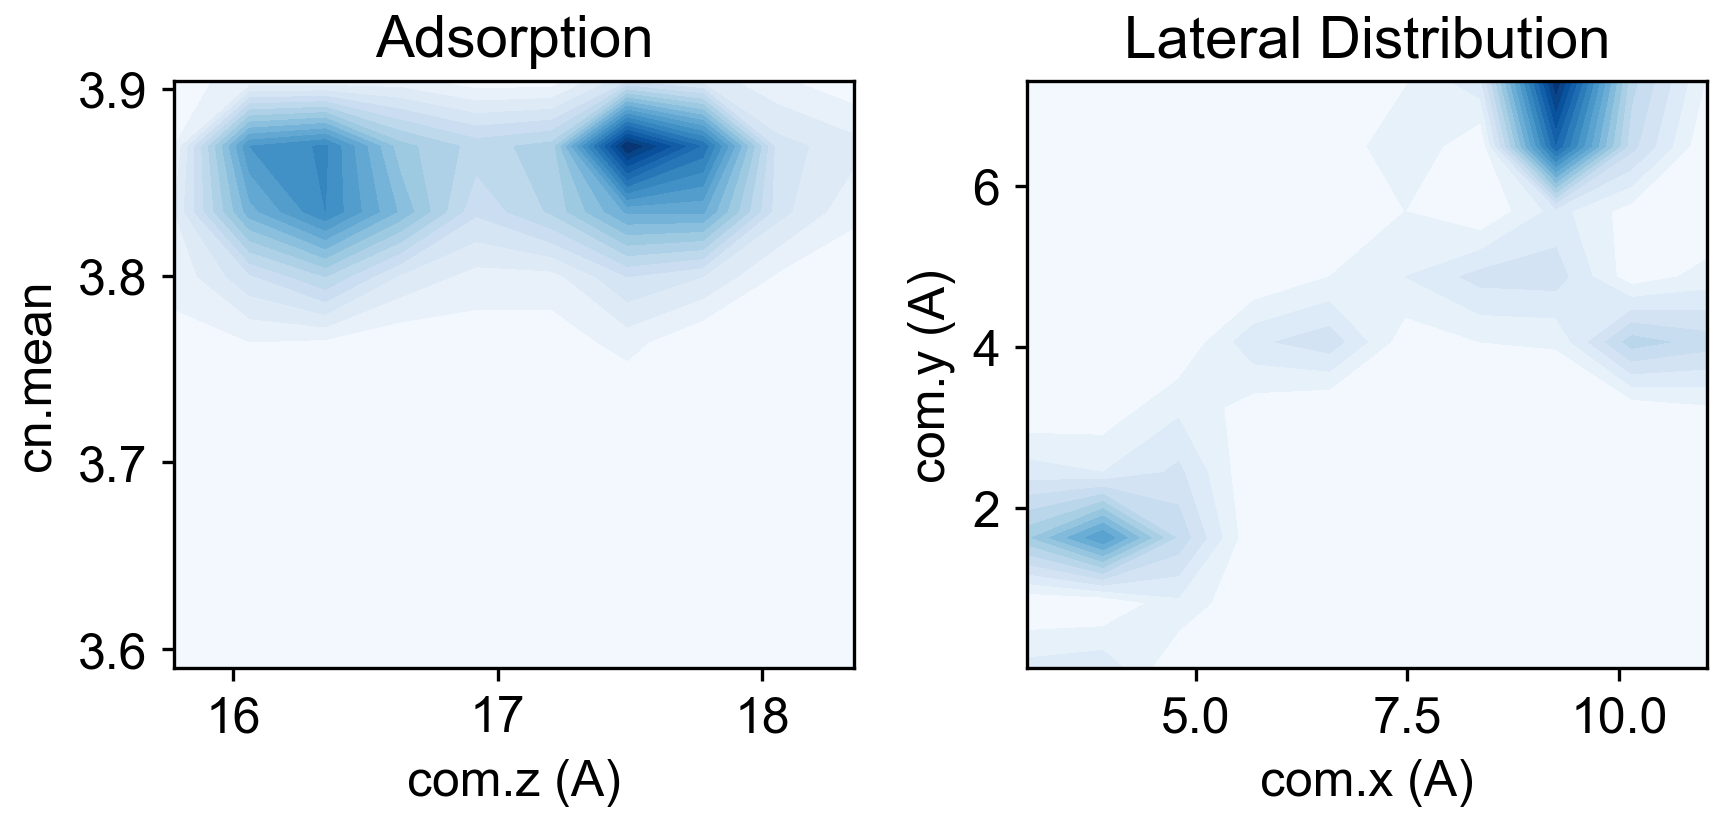

In [284]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), tight_layout=True)
ax[0].contourf(dos_diff[1][:-1], dos_diff[2][:-1], dos_diff[0], levels=20, cmap='Blues')
ax[0].set_xlabel('com.z (A)')
ax[0].set_ylabel('cn.mean')
ax[0].set_title('Adsorption')
xy_dos_ads = dos_2D(cv_diff['com.x'], cv_diff['com.y'], bins=[10, 10], density=False)
ax[1].contourf(xy_dos_diff[1][:-1], xy_dos_diff[2][:-1], xy_dos_diff[0], levels=20, cmap='Blues')
ax[1].set_xlabel('com.x (A)')
ax[1].set_ylabel('com.y (A)')
ax[1].set_title('Lateral Distribution')

In [285]:
mdb, mcv_diff = metropolis_sampling("diffMD.traj", "diff.COLVAR", calc=False, temp=4000)
#mcv_ads = plumed_to_pandas(rtype + '.COLVAR')
mdos_diff = dos_2D(mcv_diff['com.z'], mcv_diff['cn_mean'], bins=[10, 10], density=False)
mxy_dos_diff = dos_2D(cart_xy[:, 0], cart_xy[:, 1], bins=[10, 10], density=False)

# Filter the sampled database based on z and energy
mdb_index = list(range(len(mdb)))
mdb_index.sort(key=lambda i: (mcv_diff['com.z'].iloc[i], mdb[i].get_potential_energy()))

Metropolis Sampling:   0%|          | 0/1001 [00:00<?, ?it/s]/var/folders/zx/j6djtfr16010vng0mhcs8bn80000gn/T/ipykernel_52202/3846051625.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tmp_atom.calc.results['energy'] = float(ene)
Metropolis Sampling: 100%|██████████| 1001/1001 [00:00<00:00, 12205.26it/s]


Text(0.5, 1.0, 'Lateral Distribution (MS)')

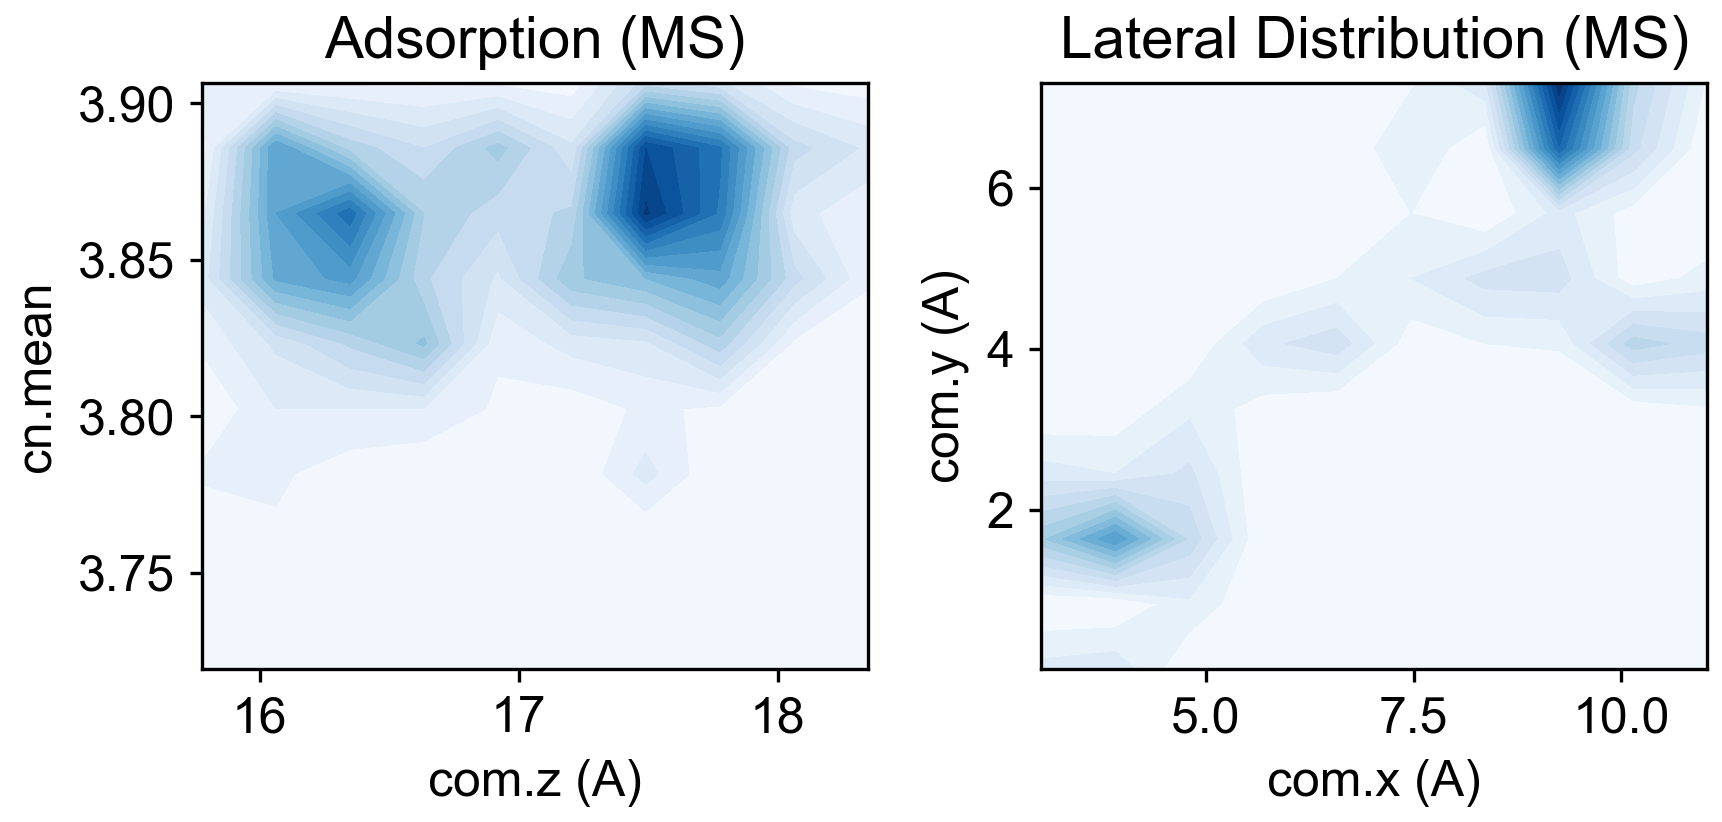

In [286]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), tight_layout=True)
ax[0].contourf(mdos_diff[1][:-1], mdos_diff[2][:-1], mdos_diff[0], levels=20, cmap='Blues')
ax[0].set_xlabel('com.z (A)')
ax[0].set_ylabel('cn.mean')
ax[0].set_title('Adsorption (MS)')
ax[1].contourf(mxy_dos_diff[1][:-1], mxy_dos_diff[2][:-1], mxy_dos_diff[0], levels=20, cmap='Blues')
ax[1].set_xlabel('com.x (A)')
ax[1].set_ylabel('com.y (A)')
ax[1].set_title('Lateral Distribution (MS)')

In [287]:
view([mdb[i] for i in mdb_index[:10]])

<Popen: returncode: None args: ['/Users/c_yang/repo/GS_GMLIP/.venv/bin/pytho...>

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/ase/gui/pipe.py", line 34, in <module>
    main()
  File "/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/ase/gui/pipe.py", line 30, in main
    plt.show()
  File "/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 614, in show
    return _get_backend_mod().show(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/matplotlib_inline/backend_inline.py", line 90, in show
    display(
  File "/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/IPython/core/display_functions.py", line 245, in display
    print(*objs)
ValueError: I/O operation on closed file.


# Reaction descriptor

In [292]:
timestep = 1 * units.fs
ps = 1000 * units.fs
temp = 700 #K

com = [i + 1 for i in range(len(fe110)) if fe110.get_tags()[i] == 0]
fe_sur = [i + 1 for i in range(len(fe110)) if fe110.get_tags()[i] == 1 and fe110.positions[i][2] > z_max - 1.5]

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"cn_mol: COORDINATIONNUMBER SPECIESA={str(com[0])} SPECIESB={','.join(map(str, com[1:]))} " +
         " SWITCH={RATIONAL R_0=1.5 NN=8 MM=16 D_MAX=8} MIN={BETA, 0.02}",
         f"cn_mx: COORDINATIONNUMBER SPECIESA={','.join(map(str, fe_sur))} SPECIESB={','.join(map(str, com))} " +
         " SWITCH={RATIONAL R_0=2.0 NN=8 MM=16 D_MAX=8} MAX={BETA, 5}",
         "opes: OPES_METAD_EXPLORE ARG=cn_mol.min,cn_mx.max PACE=200 BARRIER=0.5",
         #f"uwall: UWALLS DATA= AT={z_buff[1]} KAPPA=2000 EXP=2",
         "PRINT ARG=cn_mol.min,cn_mx.max STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = mdb[mdb_index[0]].copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=units.kB*temp)

dyn = Langevin(atoms, timestep, temperature_K=temp, friction=1,
               fixcm=True, trajectory='UnbiasMD.traj')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 52
PLUMED: File suffix: 
PLUMED: Timestep: 0.001000
PLUMED: KbT: 5.820122
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

True

In [299]:
rtype = 'dehyd'
cv_dehyd = plumed_to_pandas(rtype + '.COLVAR')

cn_dos_dehyd = dos_2D(cv_dehyd['cn_mol_min'], cv_dehyd['cn_mx_max'], bins=[10, 10], density=False)

In [304]:
mdb, mcv_dehyd = metropolis_sampling(f"{rtype}.traj", f"{rtype}.COLVAR", calc=False, temp=4000)
#mcv_ads = plumed_to_pandas(rtype + '.COLVAR')
mdos_dehyd = dos_2D(mcv_dehyd['cn_mol_min'], mcv_dehyd['cn_mx_max'], bins=[10, 10], density=False)

# Filter the sampled database based on z and energy
mdb_index = list(range(len(mdb)))
mdb_index.sort(key=lambda i: (mcv_dehyd['cn_mol_min'].iloc[i], mdb[i].get_potential_energy()))

PLUMED:                                               Cycles        Total      Average      Minimum      Maximum
PLUMED:                                                    1     0.002337     0.002337     0.002337     0.002337
PLUMED:                                               Cycles        Total      Average      Minimum      Maximum
PLUMED:                                                    1     0.358752     0.358752     0.358752     0.358752
PLUMED: 1 Prepare dependencies                         10001     0.018810     0.000002     0.000001     0.000020
PLUMED: 2 Sharing data                                 10001     0.021180     0.000002     0.000001     0.000013
PLUMED: 3 Waiting for data                             10001     0.022324     0.000002     0.000001     0.000027
PLUMED: 4 Calculating (forward loop)                   10001     0.051786     0.000005     0.000002     0.000046
PLUMED: 5 Applying (backward loop)                     10001     0.030173     0.000003     0.000

Metropolis Sampling:   0%|          | 0/1001 [00:00<?, ?it/s]/var/folders/zx/j6djtfr16010vng0mhcs8bn80000gn/T/ipykernel_52202/3846051625.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tmp_atom.calc.results['energy'] = float(ene)
Metropolis Sampling: 100%|██████████| 1001/1001 [00:00<00:00, 11705.55it/s]


Text(0, 0.5, 'cn_mx_max')

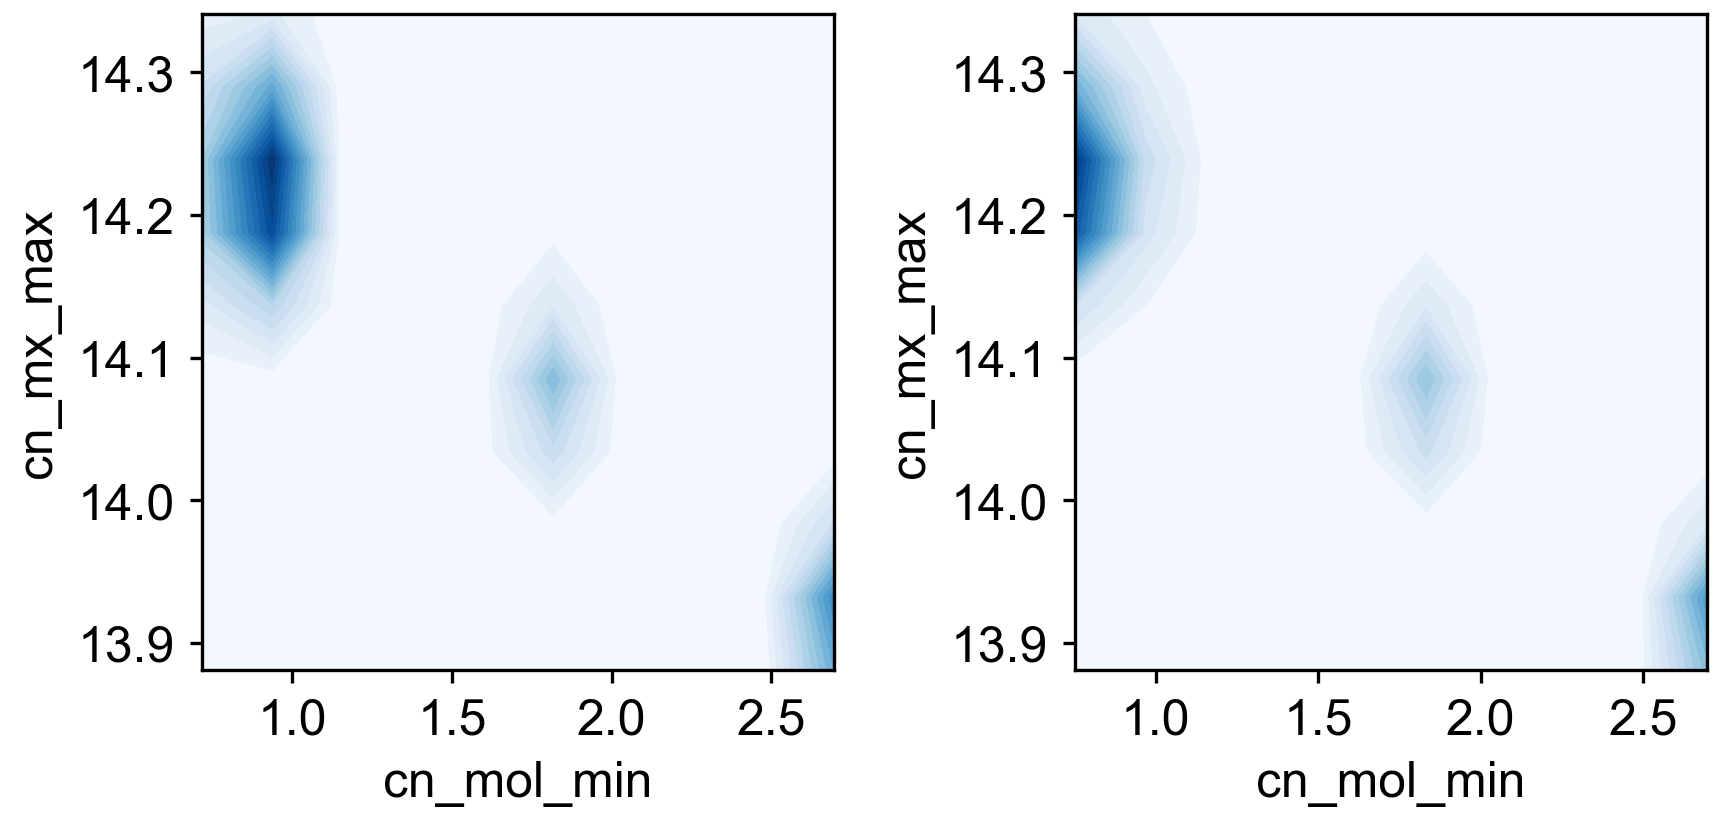

In [305]:
fig, ax = plt.subplots(1, 2, figsize=(6,3), tight_layout=True)
ax[0].contourf(cn_dos_dehyd[1][:-1], cn_dos_dehyd[2][:-1], cn_dos_dehyd[0], levels=20, cmap='Blues')
ax[0].set_xlabel('cn_mol_min')
ax[0].set_ylabel('cn_mx_max')

ax[1].contourf(mdos_dehyd[1][:-1], mdos_dehyd[2][:-1], mdos_dehyd[0], levels=20, cmap='Blues')
ax[1].set_xlabel('cn_mol_min')
ax[1].set_ylabel('cn_mx_max')

# Oxidation descriptor

In [308]:
mol_o2 = molecule("O2")
slab = mdb[mdb_index[-1]].copy()
num_slab = len(slab)
# Extrar library
mol_o2.positions[:, 2] += z_buff[0] - mol_o2.positions[:, 2].min()
slab += mol_o2
for i, atom in enumerate(range(len(mol_o2))):
    slab[num_slab + i].tag = 2  # O2 tag

In [324]:
rtype = "oxi"
timestep = 1 * units.fs
ps = 1000 * units.fs
temp = 700 #K

com = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 0]
extra = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 2]
fe_sur = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 1 and slab.positions[i][2] > z_max - 1.5]

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"com: COM ATOMS={','.join(map(str, extra))}",
         f"cn_mol: COORDINATIONNUMBER SPECIESA={str(com[0])} SPECIESB={','.join(map(str, com[1:]+extra))} " +
         " SWITCH={RATIONAL R_0=1.5 NN=8 MM=16 D_MAX=8} MIN={BETA, 0.02}",
        #  f"cn_extra: COORDINATIONNUMBER SPECIESA={','.join(map(str, fe_sur))} SPECIESB={','.join(map(str, extra))} " +
        #  " SWITCH={RATIONAL R_0=2.0 NN=8 MM=16 D_MAX=8} MAX={BETA, 5}",
         "opes: OPES_METAD_EXPLORE ARG=cn_mol.min,com.z PACE=200 BARRIER=0.6",
         f"uwall: UWALLS DATA=com.z AT={z_buff[1]} KAPPA=20000 EXP=2",
         "PRINT ARG=cn_mol.min,com.z STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = slab.copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=units.kB*temp)

dyn = Langevin(atoms, timestep, temperature_K=temp, friction=1,
               fixcm=True, trajectory=f'{rtype}MD.traj')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 54
PLUMED: File suffix: 
PLUMED: Timestep: 0.001000
PLUMED: KbT: 5.820122
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

True

In [343]:
mol_h2o = molecule("H2O")
slab = mdb[mdb_index[-1]].copy()
num_slab = len(slab)
# Extrar library
mol_h2o.positions[:, 2] += z_buff[0] - mol_h2o.positions[:, 2].min()
slab += mol_h2o
for i, atom in enumerate(range(len(mol_h2o))):
    slab[num_slab + i].tag = 2  # H2O tag

In [346]:
rtype = "water"
timestep = 1 * units.fs
ps = 1000 * units.fs
temp = 700 #K

com = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 0]
extra = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 2]
fe_sur = [i + 1 for i in range(len(slab)) if slab.get_tags()[i] == 1 and slab.positions[i][2] > z_max - 1.5]

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"com_1: COM ATOMS={','.join(map(str, extra))}",
         f"com_2: COM ATOMS={','.join(map(str, com))}",
         f"cn_mol: COORDINATIONNUMBER SPECIESA={str(com[0])} SPECIESB={','.join(map(str, com[1:]))} " +
         " SWITCH={RATIONAL R_0=1.5 NN=8 MM=16 D_MAX=8} MIN={BETA, 0.02}",
         f"cn_extra: COORDINATIONNUMBER SPECIESA={','.join(map(str, extra))} SPECIESB={','.join(map(str, com))} " +
         " SWITCH={RATIONAL R_0=2.0 NN=8 MM=16 D_MAX=8} MIN={BETA, 0.02}",
         # "com: MATHEVAL ARG=com_1.z,com_2.z FUNC=x+y PERIODIC=NO",
         "opes: OPES_METAD_EXPLORE ARG=cn_mol.min,cn_extra.min PACE=200 BARRIER=2.0",
         f"uwall_1: UWALLS DATA=com_1.z AT={z_buff[1]} KAPPA=20000 EXP=2",
         f"uwall_2: UWALLS DATA=com_2.z AT={z_buff[1]} KAPPA=20000 EXP=2",
         "PRINT ARG=cn_mol.min,cn_extra.min,com_1.z,com_2.z,uwall_1.bias,uwall_2.bias STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = slab.copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=units.kB*temp)

dyn = Langevin(atoms, timestep, temperature_K=temp, friction=1,
               fixcm=True, trajectory=f'{rtype}MD.traj')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 55
PLUMED: File suffix: 
PLUMED: Timestep: 0.001000
PLUMED: KbT: 5.820122
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

True

In [ ]:
def ssw_sampling(structure, colvar, temp=300):
    # Perform the stochastic surface walking (SSW) sampling
    pass


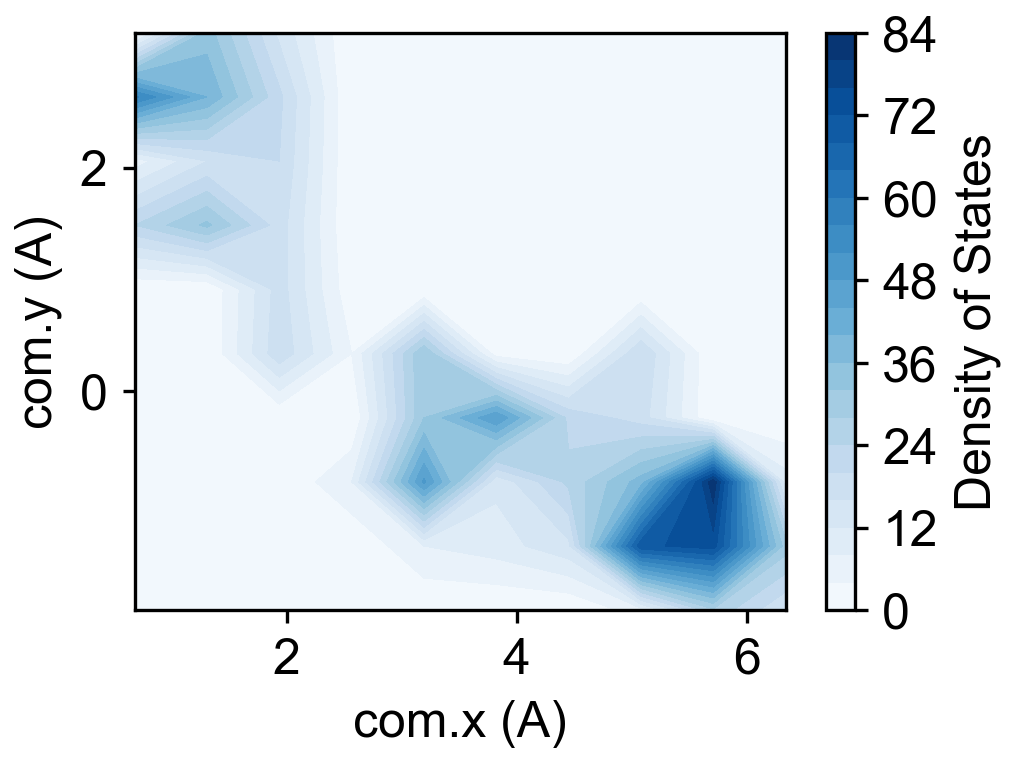

In [ ]:

plt.contourf(xy_dos_ads[1][:-1], xy_dos_ads[2][:-1], xy_dos_ads[0], levels=20, cmap='Blues')
plt.xlabel('com.x (A)')
plt.ylabel('com.y (A)')
plt.colorbar(label = 'Density of States')

# Diffusion descriptor

# Reaction descriptor

In [11]:
slab = fcc100('Pt', size=(4, 4, 4), vacuum=10.0)
slab.set_tags([1]*len(slab))  # Tag all slab atoms with 1
z_max = slab.positions[:, 2].max()
z_min = slab.positions[:, 2].min()
slab.set_constraint(FixAtoms(mask=slab.positions[:, 2] < (0.5 + 0.5 * (z_max + z_min))))

reactants_lib = [molecule('CO2'), molecule('CO'), molecule('H2O')]
for reactant in reactants_lib:
    reactant.positions[:, 2] -= reactant.positions[:, 2].min()

In [12]:
# Randomly select one reactant from the library and add it to the slab

selected_reactant = random.choice(reactants_lib)
print("Selected reactant:", selected_reactant)

selected_reactant.translate([0.0, 0.0, z_max + 2.0])
slab_with_reactant = slab + selected_reactant
print("Combined system has", len(slab_with_reactant), "atoms.")

Selected reactant: Atoms(symbols='CO2', pbc=False)
Combined system has 67 atoms.


In [13]:
view(slab_with_reactant, viewer="x3d")

In [14]:
def get_bonding_matrix(atoms, scale_factor=1.2):
    covalent_radii_array = covalent_radii[atoms.get_atomic_numbers()]
    cutoffs = covalent_radii_array * scale_factor
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    bonding_matrix = nl.get_connectivity_matrix(sparse=True)
    return bonding_matrix

def judge_saturation_molecule(atoms):
    molecular_index = np.argwhere(atoms.get_tags() == 0)[0]
    saturation = np.min(np.abs(atoms.numbers - np.array([2, 10, 18]).reshape(-1, 1)), axis=0)
    saturation[~molecular_index] = 0  # Reduce saturation by 1 for molecular atoms
    # For elements likely have lone pairs, increase saturation by 0.5
    for i in molecular_index:
        if atoms[i].symbol in ['O', 'N', 'F', 'Cl', 'S', 'P', 'Se']:
            print(saturation[i])
            saturation[i] += 0.5
    return saturation

def get_conn_matrix(atoms, bonding_matrix):
    molecular_index = atoms.get_tags() == 0
    conn_matrix = np.sum(bonding_matrix, axis=1)
    conn_matrix[~molecular_index, :] = 0
    return conn_matrix

def select_molecule_sites(atoms, bonding_matrix):
    conn_matrix = get_conn_matrix(atoms, bonding_matrix)
    saturation = judge_saturation_molecule(atoms)
    unsaturated_sites = []
    for i, atom in enumerate(atoms):
        if atoms.get_tags()[i] == 0:
            bonded_atoms = conn_matrix[i].nonzero()[1]
            if len(bonded_atoms) < saturation[i]:
                unsaturated_sites.append(i)
    return unsaturated_sites

def possible_bonding_length(atoms, scale_factor=1.2):
    numbers = [int(i) for i in set(atoms.get_atomic_numbers())]
    cl_dict = dict.fromkeys(numbers, 0)
    cl_list = []
    for num1 in numbers:
        for num2 in numbers:
            cl_list.append((covalent_radii[num1] + covalent_radii[num2]) * scale_factor)
        cl_dict[int(num1)] = np.array(cl_list).max()
    return cl_dict

In [6]:
bonding_matrix = get_bonding_matrix(slab_with_reactant)
unsaturated_sites = select_molecule_sites(slab_with_reactant, bonding_matrix)
max_bl = possible_bonding_length(slab_with_reactant)
print("Unsaturated sites in the molecule:", unsaturated_sites,
      "\nelements:", slab_with_reactant[unsaturated_sites].symbols,
      "\nmax_distance", max_bl[int(slab_with_reactant.numbers[unsaturated_sites[0]])])

surface_indices = np.argwhere(slab_with_reactant.get_tags() == 1).flatten() + 1

2
Unsaturated sites in the molecule: [64, 65] 
elements: OC 
max_distance 2.424


# Enhanced sampling methods

In [17]:
from mace.calculators import mace_mp

from ase.calculators.plumed import Plumed
from ase.md.langevin import Langevin
from ase.io import read, write
from ase import units

os.environ["PLUMED_KERNEL"] = "/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib"
calc = mace_mp(model="/Users/c_yang/Documents/play_with_code/mace/mace/calculators/foundations_models/mace-mpa-0-medium.model")

Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


/Users/c_yang/repo/GS_GMLIP/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


## Surface adsorption diffusion simulation with PLUMED OPES

In [ ]:
timestep = 0.5
ps = 1000 * units.fs

setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"com: COM ATOMS={','.join(map(str, [i+1 for i in range(len(slab_with_reactant)) if slab_with_reactant.get_tags()[i] == 0]))}",
         "opes: OPES_METAD_EXPLORE ARG=c1.mean,d1 PACE=200 BARRIER=0.5",
         "PRINT ARG=c1.*,d1,opes.* STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = slab_with_reactant.copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=0.1)

dyn = Langevin(atoms, timestep, temperature_K=0.1/units.kB, friction=1,
               fixcm=False, trajectory='UnbiasMD.xyz')

dyn.run(10000)

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 67
PLUMED: File suffix: 
PLUMED: Timestep: 0.005090
PLUMED: KbT: 9.648533
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

KeyboardInterrupt: 

In [ ]:
setup = [f"UNITS LENGTH=A TIME={1/ps} ENERGY={units.mol/units.kJ}",
         f"c1: COORDINATIONNUMBER SPECIESA=65 SPECIESB={','.join(map(str, surface_indices))}" +
         " SWITCH={RATIONAL R_0=2.4 NN=8 MM=16} MAX={BETA=2.0}",
         "OPES_METAD_EXPLORE ARG=c1 PACE=200 BARRIER=50",
         "PRINT ARG=c1.* STRIDE=10 FILE=COLVAR",
         "FLUSH STRIDE=10"]

atoms = slab_with_reactant.copy()
atoms.calc = Plumed(calc=calc,
                    input=setup,
                    timestep=timestep,
                    atoms=atoms,
                    kT=0.1)

dyn = Langevin(atoms, timestep, temperature_K=0.1/units.kB, friction=1,
               fixcm=False, trajectory='UnbiasMD-2.traj')

dyn.run(10000)

PLUMED: PLUMED is starting
PLUMED: Version: 2.11.0-dev (git: c6e517e93) compiled on Oct 18 2025 at 23:40:22
PLUMED: Please cite these papers when using PLUMED [1][2]
PLUMED: For further information see the PLUMED web page at http://www.plumed.org
PLUMED: Root: /Users/c_yang/repo/plumed2_fork/build/lib/plumed
PLUMED: LibraryPath: /Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib
PLUMED: For installed feature, see /Users/c_yang/repo/plumed2_fork/build/lib/plumed/src/config/config.txt
PLUMED: Molecular dynamics engine: ASE
PLUMED: Precision of reals: 8
PLUMED: Running over 1 node
PLUMED: Number of threads: 1
PLUMED: Cache line size: 512
PLUMED: Number of atoms: 67
PLUMED: File suffix: 
PLUMED: Timestep: 0.000051
PLUMED: KbT: 9.648533
PLUMED: Relevant bibliography:
PLUMED:   [1] The PLUMED consortium, Nat. Methods 16, 670 (2019)
PLUMED:   [2] Tribello, Bonomi, Branduardi, Camilloni, and Bussi, Comput. Phys. Commun. 185, 604 (2014)
PLUMED: Please read and cite where appropriat

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/Users/c_yang/repo/plumed2_fork/build/lib/libplumedKernel.dylib" +++


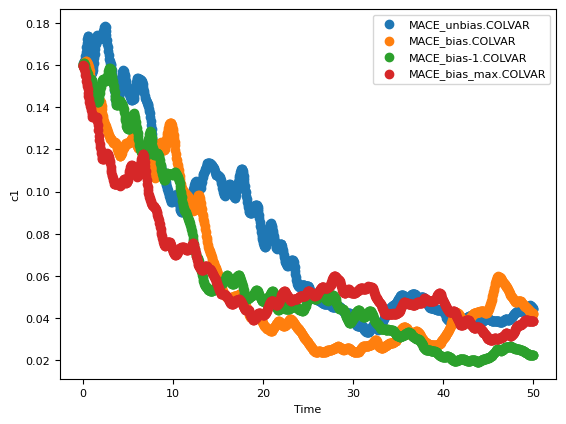

In [ ]:
filename = ["MACE_unbias.COLVAR","MACE_bias.COLVAR", "MACE_bias-1.COLVAR", "MACE_bias-2.COLVAR", "MACE_bias_max.COLVAR"]
df_1 = plumed_to_pandas(filename[0])
df_2 = plumed_to_pandas(filename[1])
df_3 = plumed_to_pandas(filename[2])
df_4 = plumed_to_pandas(filename[3])
df_5 = plumed_to_pandas(filename[4])
plt.scatter(df_1["time"], df_1["c1_min"], label=filename[0])
plt.scatter(df_2["time"], df_2["c1_min"], label=filename[1])
plt.scatter(df_3["time"], df_3["c1_min"], label=filename[2])
#plt.scatter(df_4["time"], df_4["c1_max"], label=filename[3])
plt.scatter(df_5["time"], df_5["c1_max"], label=filename[4])
plt.xlabel("Time")
plt.ylabel("c1")
plt.legend()

In [ ]:
def get_random_normal_vector():
    vec = np.random.normal(0, 1, 3)
    vec /= np.linalg.norm(vec)
    return vec

# Reaction pair construction

## Possible reaction type:
* Adsorption / Desorption
* Hydrogenation / Dehydrogenation 
* Association / Dissociation
* Surface reaction (Eley-Rideal, Langmuir-Hinshelwood)
* Diffusion (surface diffusion, bulk diffusion)